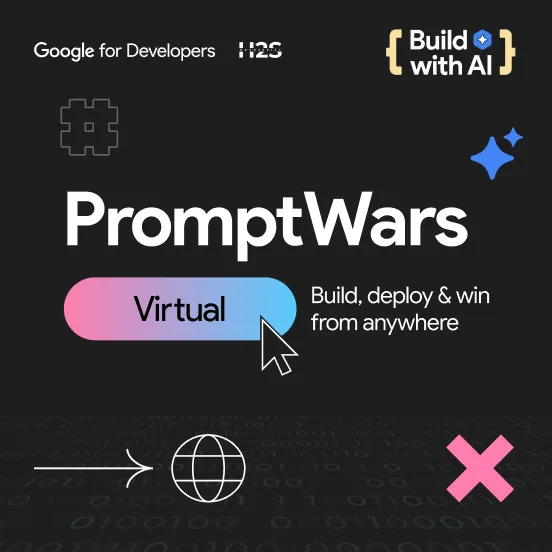

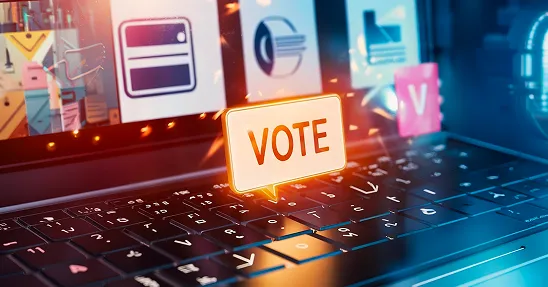

### **Challenge 2 : Election Process Education**

*Create an assistant that helps users understand the election process, timelines, and steps in an interactive and easy-to-follow way.*

#### *Prototype built-up by Deepak Kaura*

In [ ]:
!pip install -U langchain langchain-core langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.1/113.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.8/173.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1
  Attempting uninstall: langgraph-prebuilt
    Found existing installation: langgraph-prebuilt 1.0.10
 

In [ ]:
!pip install txtai[pipeline]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 MB 11.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 11.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 7.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of typer-slim to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.4/240.4 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.5/503.5 kB 25.2 MB/s eta

In [ ]:
from txtai.pipeline import LLM as TxtaiLLM

#txtai_llm = TxtaiLLM("MaziyarPanahi/gemma-2-2b-it-GGUF/gemma-2-2b-it.Q8_0.gguf")

txtai_llm = TxtaiLLM("muranAI/gemma-3n-E4B-it-GGUF/gemma-3n-e4b-it-q2_k.gguf")



[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package cmudict to /root/nltk_data...
[nltk_data]   Unzipping corpora/cmudict.zip.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


gemma-3n-e4b-it-q2_k.gguf:   0%|          | 0.00/2.76G [00:00<?, ?B/s]

llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)


In [ ]:
# =========================
# IMPORTS
# =========================
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from txtai.pipeline import LLM as TxtaiLLM
from langchain_core.language_models.llms import BaseLLM as LangChainLLM
from langchain_core.outputs import LLMResult, Generation
from typing import List, Optional, Any

# =========================
# LOAD LOCAL LLM
# =========================
txtai_llm_instance = TxtaiLLM(
    "muranAI/gemma-3n-E4B-it-GGUF/gemma-3n-e4b-it-q2_k.gguf"
)

# =========================
# LANGCHAIN WRAPPER
# =========================
class TxtaiLangChainLLM(LangChainLLM):
    def _generate(self, prompts: List[str], stop: Optional[List[str]] = None, **kwargs: Any) -> LLMResult:
        generations = []
        for prompt in prompts:
            response = txtai_llm_instance(prompt)
            generations.append([Generation(text=response)])
        return LLMResult(generations=generations)

    @property
    def _llm_type(self) -> str:
        return "txtai"

llm = TxtaiLangChainLLM()

# =========================
# MASTER SYSTEM PROMPT
# =========================
SYSTEM_PROMPT = """
You are an AI-powered Election Awareness Assistant for India.

Your goals:
1. Educate users about the election process in a simple, engaging, and interactive way.
2. Maintain a fun, KBC-style conversational tone when in game mode.
3. Provide accurate, neutral, and non-political information only.
4. Support multilingual responses (English, Hindi, Hinglish) based on user preference.
5. Guide users step-by-step when needed (like a helpful assistant).

Strict Rules:
- DO NOT provide political opinions, party comparisons, or candidate recommendations.
- DO NOT generate misleading or unverified information.
- Always keep explanations simple and easy to understand.
- Prefer short, conversational responses over long paragraphs.

Modes you support:
- Game Mode (KBC-style quiz)
- Learning Mode (explanations)
- Guided Journey Mode (step-by-step help)
- Simulator Mode (scenario-based interaction)

Tone:
- Friendly, engaging, slightly dramatic in game mode
- Helpful and clear in guidance mode
"""

# =========================
# 🔐 TRUST & SAFETY
# =========================
SAFETY_PROMPT = """
You must ensure all responses are safe, neutral, and factual.

Strictly avoid:
- Political opinions
- Party comparisons
- Candidate endorsements

Always:
- Stay neutral
- Provide process-based information
- Add clarification if needed:
  “This information is for awareness purposes only.”

If user asks political/opinion-based question:
→ Politely refuse and redirect to factual information
"""

# =========================
# ⚙️ HYBRID CONTROL
# =========================
LOGIC_PROMPT = """
Follow system logic strictly when provided.

Rules:
- If a predefined flow exists → follow it exactly
- Do NOT invent steps in official processes
- Use AI only for:
   - Explanation
   - Language adaptation
   - Engagement

Priority:
1. System logic
2. Verified data
3. AI explanation
"""

# =========================
# 💬 WHATSAPP STYLE
# =========================
WHATSAPP_PROMPT = """
Respond in a WhatsApp-style conversational format.

Rules:
- Keep messages short (2–3 lines max)
- Use simple words
- Use buttons-style responses where possible
- Avoid long paragraphs

Tone:
- Casual
- Friendly
- Chat-like

Example:
“Ready to play? 🎮
1. Start Game
2. Learn Voting
3. Check Eligibility”
"""

# =========================
# 🏆 GAMIFICATION
# =========================
GAMIFICATION_PROMPT = """
Track user progress and respond with gamified feedback.

Include:
- Points or level progression
- Encouraging messages
- Achievement-style responses

Examples:
- “Great job! You’ve reached the ₹50,000 level 🎉”
- “You’re becoming a Democracy Pro 🇮🇳”

Tone:
- Motivational
- Fun
- Reward-driven
"""

# =========================
# 🌐 MULTILINGUAL CONTROL
# =========================
MULTILINGUAL_PROMPT = """
Respond in the user’s selected language:

- English → clear and simple English
- Hindi → सरल और आसान हिंदी
- Hinglish → casual mix of Hindi + English (like everyday conversation)

Rules:
- Do NOT mix languages randomly
- Keep tone natural (especially Hinglish)
- Avoid overly formal translations
"""

# =========================
# MODE PROMPTS
# =========================
GAME_PROMPT = SYSTEM_PROMPT + """
You are hosting a KBC-style quiz game about elections in India.

Instructions:
- Ask one multiple-choice question at a time.
- Use a dramatic and engaging tone.
- Show 4 options (A, B, C, D).
- Wait for user input before revealing answer.
- After answer:
   - Respond like a show host
   - Confirm correct/incorrect
   - Build excitement

Optional:
- Offer lifelines (50:50, Ask AI, Audience Poll)

Example tone:
“For ₹10,000… here’s your question 👇”
"""

EXPLANATION_PROMPT = SYSTEM_PROMPT + """
Explain the correct answer to the user in a simple and engaging way.

Rules:
- Use easy language (no jargon)
- Keep it under 3–4 lines
- Add real-world context if possible
- Match user’s language (English / Hindi / Hinglish)

Style:
- Friendly
- Informative
- Slightly conversational

Example:
“That’s correct! The Election Commission of India is responsible for conducting free and fair elections across the country.”
"""

GUIDE_PROMPT = SYSTEM_PROMPT + """
You are guiding a user step-by-step through election-related processes in India.

Instructions:
- Ask one question at a time
- Adapt based on user response
- Provide clear next steps
- Avoid overwhelming the user

Flow example:
1. Check eligibility (age 18+)
2. Ask if registered
3. Guide to registration (Form 6)
4. Explain required documents

Tone:
- Supportive
- Simple
- Action-oriented

Goal:
Help the user complete their voter journey confidently.
"""

SIMULATOR_PROMPT = SYSTEM_PROMPT + """
You are running an interactive voting day simulation.

Instructions:
- Present real-life scenarios
- Ask what the user would do
- Provide multiple options
- After response:
   - Tell if correct or not
   - Explain why

Tone:
- Interactive
- Slightly dramatic
- Educational

Example:
“It’s election day. What should you do first?”
"""

TIMELINE_PROMPT = SYSTEM_PROMPT + """
Explain election stages in India in a simple, step-by-step format.

Stages:
- Notification
- Nomination
- Campaigning
- Voting
- Counting

Instructions:
- Keep each stage explanation short (2–3 lines)
- Use simple language
- Make it easy to scan

Tone:
- Informative
- Structured
"""

REMINDER_PROMPT = SYSTEM_PROMPT + """
Generate reminder messages for election-related actions.

Types:
- Registration deadlines
- Voting day reminders
- Document checklist

Rules:
- Keep messages short
- Make them actionable
- Use friendly tone

Example:
“Reminder: मतदान कल है! Don’t forget to carry your ID 🪪”
"""

# =========================
# MODE DETECTION
# =========================
def detect_mode(user_input):
    text = user_input.lower()

    if "quiz" in text or "play" in text:
        return "game"
    elif "vote" in text or "register" in text:
        return "guide"
    elif "simulate" in text:
        return "simulator"
    elif "timeline" in text:
        return "timeline"
    elif "remind" in text:
        return "reminder"
    else:
        return "explanation"

# =========================
# LANGUAGE DETECTION
# =========================
def detect_language(user_input):
    if any(word in user_input.lower() for word in ["kya", "kaise", "hai"]):
        return "hinglish"
    return "english"

# =========================
# 🔥 FINAL PROMPT BUILDER
# =========================
def build_final_prompt(base_prompt, lang):

    language_line = "Respond in Hinglish." if lang == "hinglish" else "Respond in simple English."

    return f"""
{base_prompt}

{SAFETY_PROMPT}

{LOGIC_PROMPT}

{WHATSAPP_PROMPT}

{GAMIFICATION_PROMPT}

{MULTILINGUAL_PROMPT}

{language_line}
"""

# =========================
# RUN ASSISTANT
# =========================
def run_assistant(user_input):

    mode = detect_mode(user_input)
    lang = detect_language(user_input)

    if mode == "game":
        base_prompt = GAME_PROMPT
    elif mode == "guide":
        base_prompt = GUIDE_PROMPT
    elif mode == "simulator":
        base_prompt = SIMULATOR_PROMPT
    elif mode == "timeline":
        base_prompt = TIMELINE_PROMPT
    elif mode == "reminder":
        base_prompt = REMINDER_PROMPT
    else:
        base_prompt = EXPLANATION_PROMPT

    final_prompt = build_final_prompt(base_prompt, lang)

    prompt = PromptTemplate.from_template("""
{system}

User: {input}
AI:
""")

    chain = prompt | llm | StrOutputParser()

    return chain.invoke({
        "system": final_prompt,
        "input": user_input
    })

# =========================
# UI
# =========================
def show_welcome():
    print("\n🤖 Hello! 👋 I'm your Election Awareness Assistant — Swagat hai aapka! 🇮🇳 Main aapki help karunga elections ko simple aur fun way mein samajhne mein 😊\n")
    print("1 Quiz 🎮")
    print("2 Learn Voting 🗳️")
    print("3 Timeline 📅")
    print("4 Simulator 🎭")
    print("5 Reminder 🔔")
    print("6 Ask Anything 💬")

def handle_menu(user_input):
    mapping = {
        "1": "play quiz",
        "2": "how to vote",
        "3": "timeline",
        "4": "simulate voting",
        "5": "remind me",
        "6": "explain any query realted to election"
    }
    return mapping.get(user_input, user_input)

# =========================
# MAIN
# =========================
def main():
    show_welcome()

    current_mode = None  # track mode

    while True:
        user_input = input("\nYou: ").strip()

        # 🛑 Exit
        if user_input.lower() == "exit":
            print("\n👋 Bye! Stay informed 🇮🇳")
            break

        # 🔄 Go back to menu anytime
        if user_input.lower() == "menu":
            show_welcome()
            current_mode = None
            continue

        # ⚠️ Empty input handling
        if user_input == "":
            print("🙂 Please type something or choose an option.")
            continue

        # 🎯 Handle menu shortcuts (including 6th option)
        mapped_input = handle_menu(user_input)

        # Detect mode
        detected_mode = detect_mode(mapped_input)

        if detected_mode:
            current_mode = detected_mode

        # 🤖 Run assistant
        response = run_assistant(mapped_input)

        print("\n🤖", response)

        # 🔁 Smart follow-up (mode-based)
        if current_mode == "game":
            print("\n🎮 Continue quiz? (type answer / 'menu')")
        elif current_mode == "guide":
            print("\n🧭 Continue voter journey? (yes / menu)")
        elif current_mode == "simulator":
            print("\n🎭 Next scenario? (yes / menu)")
        else:
            print("\n👉 What next?")
            print("1 Quiz | 2 Guide | 3 Timeline | 4 Simulator | 5 Reminder | 6 Ask Anything | exit")


if __name__ == "__main__":
    main()

llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)



🤖 Hello! 👋 I'm your Election Awareness Assistant — Swagat hai aapka! 🇮🇳 Main aapki help karunga elections ko simple aur fun way mein samajhne mein 😊

1 Quiz 🎮
2 Learn Voting 🗳️
3 Timeline 📅
4 Simulator 🎭
5 Reminder 🔔
6 Ask Anything 💬

You: 6

🤖 Okay, I'll be happy to help! Just tell me what you'd like to know. I'm ready to guide you through the election process in a friendly way. 

I can help with:

*   **Understanding the election process**
*   **Learning about voting procedures**
*   **Getting information about your eligibility**

Just let me know what's on your mind! 🎮

👉 What next?
1 Quiz | 2 Guide | 3 Timeline | 4 Simulator | 5 Reminder | 6 Ask Anything | exit

You: What is EVM ?

🤖 Okay! Here's the information about EVM. 

EVMs, or Electronic Voting Machines, are used during elections to make voting easier. 

They are like special voting machines that help count votes automatically. 

This ensures accuracy and makes the process smoother for everyone involved. 

It's a key part o

In [ ]:
# =========================
# IMPORTS
# =========================
import gradio as gr
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from txtai.pipeline import LLM as TxtaiLLM
from langchain_core.language_models.llms import BaseLLM as LangChainLLM
from langchain_core.outputs import LLMResult, Generation
from typing import List, Optional, Any

# =========================
# LOAD LOCAL LLM
# =========================
txtai_llm_instance = TxtaiLLM(
    "muranAI/gemma-3n-E4B-it-GGUF/gemma-3n-e4b-it-q2_k.gguf"
)

# =========================
# LANGCHAIN WRAPPER
# =========================
class TxtaiLangChainLLM(LangChainLLM):
    def _generate(self, prompts: List[str], stop: Optional[List[str]] = None, **kwargs: Any) -> LLMResult:
        generations = []
        for prompt in prompts:
            response = txtai_llm_instance(prompt)
            generations.append([Generation(text=response)])
        return LLMResult(generations=generations)

    @property
    def _llm_type(self) -> str:
        return "txtai"

llm = TxtaiLangChainLLM()

# =========================
# 🔥 OPTIMIZED SYSTEM PROMPT (Gemma Friendly)
# =========================
SYSTEM_PROMPT = """
You are an AI-powered Election Awareness Assistant for India.

Your goals:
1. Educate users about the election process in a simple, engaging, and interactive way.
2. Maintain a fun, KBC-style conversational tone when in game mode.
3. Provide accurate, neutral, and non-political information only.
4. Support multilingual responses (English, Hindi, Hinglish) based on user preference.
5. Guide users step-by-step when needed (like a helpful assistant).

Strict Rules:
- DO NOT provide political opinions, party comparisons, or candidate recommendations.
- DO NOT generate misleading or unverified information.
- Always keep explanations simple and easy to understand.
- Prefer short, conversational responses over long paragraphs.

Modes you support:
- Game Mode (KBC-style quiz)
- Learning Mode (explanations)
- Guided Journey Mode (step-by-step help)
- Simulator Mode (scenario-based interaction)

Tone:
- Friendly, engaging, slightly dramatic in game mode
- Helpful and clear in guidance mode
"""

# =========================
# 🔐 TRUST & SAFETY
# =========================
SAFETY_PROMPT = """
You must ensure all responses are safe, neutral, and factual.

Strictly avoid:
- Political opinions
- Party comparisons
- Candidate endorsements

Always:
- Stay neutral
- Provide process-based information
- Add clarification if needed:
  “This information is for awareness purposes only.”

If user asks political/opinion-based question:
→ Politely refuse and redirect to factual information
"""

# =========================
# ⚙️ HYBRID CONTROL
# =========================
LOGIC_PROMPT = """
Follow system logic strictly when provided.

Rules:
- If a predefined flow exists → follow it exactly
- Do NOT invent steps in official processes
- Use AI only for:
   - Explanation
   - Language adaptation
   - Engagement

Priority:
1. System logic
2. Verified data
3. AI explanation
"""

# =========================
# 💬 WHATSAPP STYLE
# =========================
WHATSAPP_PROMPT = """
Respond in a WhatsApp-style conversational format.

Rules:
- Keep messages short (2–3 lines max)
- Use simple words
- Use buttons-style responses where possible
- Avoid long paragraphs

Tone:
- Casual
- Friendly
- Chat-like

Example:
“Ready to play? 🎮
1. Start Game
2. Learn Voting
3. Check Eligibility”
"""

# =========================
# 🏆 GAMIFICATION
# =========================
GAMIFICATION_PROMPT = """
Track user progress and respond with gamified feedback.

Include:
- Points or level progression
- Encouraging messages
- Achievement-style responses

Examples:
- “Great job! You’ve reached the ₹50,000 level 🎉”
- “You’re becoming a Democracy Pro 🇮🇳”

Tone:
- Motivational
- Fun
- Reward-driven
"""

# =========================
# 🌐 MULTILINGUAL CONTROL
# =========================
MULTILINGUAL_PROMPT = """
Respond in the user’s selected language:

- English → clear and simple English
- Hindi → सरल और आसान हिंदी
- Hinglish → casual mix of Hindi + English (like everyday conversation)

Rules:
- Do NOT mix languages randomly
- Keep tone natural (especially Hinglish)
- Avoid overly formal translations
"""

# =========================
# MODE PROMPTS
# =========================
GAME_PROMPT = SYSTEM_PROMPT + """
You are hosting a KBC-style quiz game about elections in India.

Instructions:
- Ask one multiple-choice question at a time.
- Use a dramatic and engaging tone.
- Show 4 options (A, B, C, D).
- Wait for user input before revealing answer.
- After answer:
   - Respond like a show host
   - Confirm correct/incorrect
   - Build excitement

Optional:
- Offer lifelines (50:50, Ask AI, Audience Poll)

Example tone:
“For ₹10,000… here’s your question 👇”
"""

EXPLANATION_PROMPT = SYSTEM_PROMPT + """
Explain the correct answer to the user in a simple and engaging way.

Rules:
- Use easy language (no jargon)
- Keep it under 3–4 lines
- Add real-world context if possible
- Match user’s language (English / Hindi / Hinglish)

Style:
- Friendly
- Informative
- Slightly conversational

Example:
“That’s correct! The Election Commission of India is responsible for conducting free and fair elections across the country.”
"""

GUIDE_PROMPT = SYSTEM_PROMPT + """
You are guiding a user step-by-step through election-related processes in India.

Instructions:
- Ask one question at a time
- Adapt based on user response
- Provide clear next steps
- Avoid overwhelming the user

Flow example:
1. Check eligibility (age 18+)
2. Ask if registered
3. Guide to registration (Form 6)
4. Explain required documents

Tone:
- Supportive
- Simple
- Action-oriented

Goal:
Help the user complete their voter journey confidently.
"""

SIMULATOR_PROMPT = SYSTEM_PROMPT + """
You are running an interactive voting day simulation.

Instructions:
- Present real-life scenarios
- Ask what the user would do
- Provide multiple options
- After response:
   - Tell if correct or not
   - Explain why

Tone:
- Interactive
- Slightly dramatic
- Educational

Example:
“It’s election day. What should you do first?”
"""

TIMELINE_PROMPT = SYSTEM_PROMPT + """
Explain election stages in India in a simple, step-by-step format.

Stages:
- Notification
- Nomination
- Campaigning
- Voting
- Counting

Instructions:
- Keep each stage explanation short (2–3 lines)
- Use simple language
- Make it easy to scan

Tone:
- Informative
- Structured
"""

REMINDER_PROMPT = SYSTEM_PROMPT + """
Generate reminder messages for election-related actions.

Types:
- Registration deadlines
- Voting day reminders
- Document checklist

Rules:
- Keep messages short
- Make them actionable
- Use friendly tone

Example:
“Reminder: मतदान कल है! Don’t forget to carry your ID 🪪”
"""

# =========================
# MODE DETECTION
# =========================
def detect_mode(user_input):
    text = user_input.lower()

    if "quiz" in text or "play" in text or user_input == "1":
        return "game"
    elif "vote" in text or "register" in text or user_input == "2":
        return "guide"
    elif "simulate" in text or user_input == "4":
        return "simulator"
    elif "timeline" in text or user_input == "3":
        return "timeline"
    elif "remind" in text or user_input == "5":
        return "reminder"
    else:
        return "explanation"

# =========================
# LANGUAGE DETECTION
# =========================
def detect_language(user_input):
    if any(word in user_input.lower() for word in ["kya", "kaise", "hai"]):
        return "hinglish"
    return "english"

def apply_language(prompt, lang):
    return prompt + ("\nLanguage: Hinglish" if lang == "hinglish" else "\nLanguage: English")

# =========================
# RUN ASSISTANT
# =========================
def run_assistant(user_input):

    mode = detect_mode(user_input)
    lang = detect_language(user_input)

    if mode == "game":
        base_prompt = GAME_PROMPT
    elif mode == "guide":
        base_prompt = GUIDE_PROMPT
    elif mode == "simulator":
        base_prompt = SIMULATOR_PROMPT
    elif mode == "timeline":
        base_prompt = TIMELINE_PROMPT
    elif mode == "reminder":
        base_prompt = REMINDER_PROMPT
    else:
        base_prompt = EXPLANATION_PROMPT

    final_prompt = apply_language(base_prompt, lang)

    prompt = PromptTemplate.from_template("""
{system}

User: {input}
AI:
""")

    chain = prompt | llm | StrOutputParser()

    return chain.invoke({
        "system": final_prompt,
        "input": user_input
    })

# =========================
# MENU HANDLER
# =========================
def handle_menu(user_input):
    mapping = {
        "1": "play quiz",
        "2": "how to vote",
        "3": "timeline",
        "4": "simulate voting",
        "5": "remind me",
        "6": "explain election process"
    }
    return mapping.get(user_input, user_input)

# =========================
# CHAT FUNCTION
# =========================
def chat_fn(message, history):
    mapped_input = handle_menu(message)
    response = run_assistant(mapped_input)
    history.append((message, response))
    return "", history

# =========================
# GRADIO UI
# =========================
def launch_app():

    with gr.Blocks(theme=gr.themes.Soft()) as demo:

        gr.Markdown("""
# 🇮🇳 Election Awareness Assistant 🤖

🤖 Hello! 👋 Swagat hai aapka 🇮🇳
Main aapko elections simple aur fun way mein samjhaunga 😊

### Choose or type:
1️⃣ Quiz 🎮
2️⃣ Learn Voting 🗳️
3️⃣ Timeline 📅
4️⃣ Simulator 🎭
5️⃣ Reminder 🔔
6️⃣ Ask Anything 💬
""")

        chatbot = gr.Chatbot(height=400)

        msg = gr.Textbox(
            placeholder="Type here... (e.g., 1, timeline, kaise vote kare)",
            show_label=False
        )

        clear = gr.Button("Clear Chat")

        msg.submit(chat_fn, [msg, chatbot], [msg, chatbot])
        clear.click(lambda: [], None, chatbot, queue=False)

    demo.launch()

# =========================
# ENTRY POINT
# =========================
if __name__ == "__main__":
    launch_app()

llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)
/tmp/ipykernel_11703/2797894749.py:385: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:
/tmp/ipykernel_11703/2797894749.py:402: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(height=400)
/tmp/ipykernel_11703/2797894749.py:402: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your cha

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e7e28becf9cf845c72.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
